# Preparation for interpolation

Confidence interval version

In [1]:
import sys
sys.path.append('../../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data

In [2]:
data=pd.read_csv('../../Data/FRB_data/FRB_new.csv')
data

,FRB,z,gl,gb,DM,"DM_MW, ISM(NE2001)","DM_MW, ISM(YMW16)",DM_ext(ne2001),DM_ext(ymw16),Ref.
0,FRB 20180814A,0.06800,136.460000,16.580000,190.90,87.83,108.41,73.073904,52.493323,CHIME13
1,FRB 20181030A,0.00385,133.400000,40.900000,103.50,40.35,32.24,33.149498,41.256729,181030A
2,FRB 20220529A,0.18390,130.787670,-41.858020,246.00,39.95,30.92,176.048832,185.076405,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01500,8.839200,-70.185700,1458.10,30.96,13.58,1397.142120,1414.521089,ASKAP2
4,FRB 20220717A,0.36295,19.835158,-17.632032,637.34,118.33,83.22,489.008396,524.116215,https://arxiv.org/pdf/2407.02173
...,...,...,...,...,...,...,...,...,...,...
112,FRB 20231204A,0.06440,97.623756,65.928145,221.00,29.83,21.79,161.171345,169.213125,https://arxiv.org/pdf/2502.11217
113,FRB 20231206A,0.06590,161.058167,27.481895,457.70,59.14,59.29,368.564132,368.411742,https://arxiv.org/pdf/2502.11217
114,FRB 20231223C,0.10590,52.310724,32.080162,165.80,47.87,38.64,87.934075,97.162328,https://arxiv.org/pdf/2502.11217
115,FRB 20231229A,0.01900,135.344911,-26.443349,198.50,58.18,51.77,110.319698,116.734467,https://arxiv.org/pdf/2502.11217


In [3]:
print(np.min(data['z']))

0.00014


In [4]:
print(f_sqrtvar_delta(1.0,np.min(data['z'])))

84.51088382744483


# Preparation interpolation

search F range 

In [5]:
sigma_rsl = 5000
sigmas = np.linspace(0.01, 85, sigma_rsl)

C0s = np.zeros_like(sigmas)
As = np.zeros_like(sigmas)

pbar = tqdm(sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = find_C0_sigma(sigma,
                 condition='mean'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A

Processing sigma=59.4809:  70%|██████▉   | 3498/5000 [13:34<11:56,  2.10it/s]

Processing sigma=59.4979:  70%|██████▉   | 3499/5000 [13:34<12:49,  1.95it/s]

Processing sigma=59.5149:  70%|███████   | 3500/5000 [13:35<12:31,  2.00it/s]

Processing sigma=59.5319:  70%|███████   | 3501/5000 [13:35<12:17,  2.03it/s]

Processing sigma=59.5489:  70%|███████   | 3502/5000 [13:36<12:24,  2.01it/s]

...

Processing sigma=84.9490: 100%|█████████▉| 4996/5000 [26:28<00:01,  2.11it/s]

Processing sigma=84.9660: 100%|█████████▉| 4997/5000 [26:28<00:01,  2.11it/s]

Processing sigma=84.9830: 100%|█████████▉| 4998/5000 [26:29<00:00,  2.11it/s]

Processing sigma=85.0000: 100%|█████████▉| 4999/5000 [26:29<00:00,  2.13it/s]

Processing sigma=85.0000: 100%|██████████| 5000/5000 [26:30<00:00,  3.14it/s]

In [6]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As)
C0s = C0s[mask]
As = As[mask]
sigmas = sigmas[mask]
print(len(sigmas), len(C0s), len(As))

3497 3497 3497


In [7]:
# sigma_rsl=5000
# # sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(sigmas),np.max(sigmas)])
# C0s=np.zeros_like(sigmas)
# As=np.zeros_like(sigmas)
# Vars_sqrt=np.zeros_like(sigmas)
# for i, sigma in enumerate(sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Vars_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

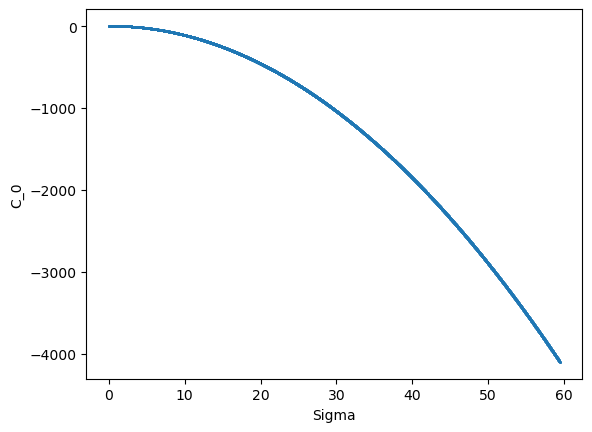

In [8]:
plt.scatter(sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

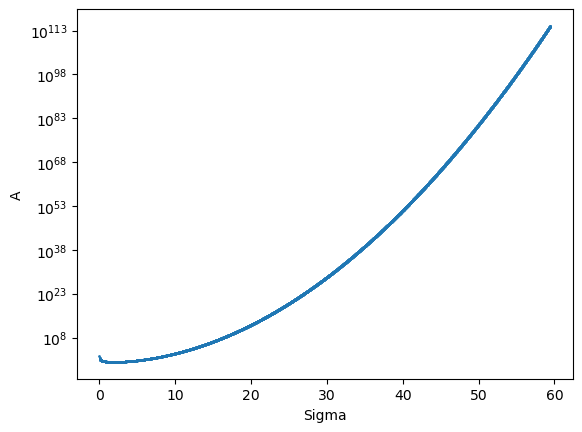

In [9]:
plt.scatter(sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

In [10]:
# interpolation example

# C0_sigma = interpolate.interp1d(sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Vars_sqrt, sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [11]:
np.savez('./interpolation/A_C0_Macquart_mean.npz', a=sigmas, b=As, c=C0s)

In [12]:
# np.save('./interpolation/sigmas.npy', sigmas)
# np.save('./interpolation/As.npy', As)
# np.save('./interpolation/C0s.npy', C0s)
# np.save('./interpolation/Vars_sqrt.npy', Vars_sqrt)